1. Download the data

In [ ]:
!mkdir -p ../data
!curl -L -o ../data/task_connections_1507.feather https://raw.githubusercontent.com/sdorkenw/ConnectomicsProgrammingTask/main/data/task_connections_1507.feather
!curl -L -o ../data/task_cell_body_locations_1507.feather https://raw.githubusercontent.com/sdorkenw/ConnectomicsProgrammingTask/main/data/task_cell_body_locations_1507.feather

2. Import libraries

In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


3. Create dataframes

In [25]:
connections_df = pd.read_feather("../data/task_connections_1507.feather")
locations_df = pd.read_feather("../data/task_cell_body_locations_1507.feather")

In [26]:
print(len(connections_df), "connections")
print(len(locations_df), "neurons with cell body locations")
print(len(connections_df["pre_pt_root_id"].unique()), "presynaptic neuron")

36320 connections
35046 neurons with cell body locations
66 presynaptic neuron


4. Implementation

Hypothesis: the further apart two cell bodies are, the less likely they are to be connected.

Goal: Create plots on x-axis will show the distance, and y will be connectivity probablity

4.1 Calculate potential neurons connected distance

In [35]:
# xyz of every neuron so I can look it up by id
all_ids = locations_df["pt_root_id"].values
all_xyz = locations_df[["pt_position_x", "pt_position_y", "pt_position_z"]].values

coords = {}
for j in range(len(all_ids)):
    coords[all_ids[j]] = all_xyz[j]

# distance for actual connections
connected_dist = []
for i in range(len(connections_df)):
    pre = connections_df["pre_pt_root_id"][i]
    post = connections_df["post_pt_root_id"][i]
    x1, y1, z1 = coords[pre]
    x2, y2, z2 = coords[post]
    d = np.sqrt((x2 - x1) ** 2 + (y2 - y1) ** 2 + (z2 - z1) ** 2)
    connected_dist.append(d)

connected_dist = np.array(connected_dist) / 1000  # nm to um
print(len(connected_dist))

36320


In [38]:
# distance from each source neuron to every other neuron
pre_ids = connections_df["pre_pt_root_id"].unique()

all_pairs_distance = []
for i in range(len(pre_ids)):
    x1, y1, z1 = coords[pre_ids[i]]
    for j in range(len(all_ids)):
        if pre_ids[i] == all_ids[j]:
            continue
        x2, y2, z2 = all_xyz[j]
        d = np.sqrt((x2 - x1) ** 2 + (y2 - y1) ** 2 + (z2 - z1) ** 2)
        all_pairs_distance.append(d)

all_pairs_distance = np.array(all_pairs_distance) / 1000  # nm to um

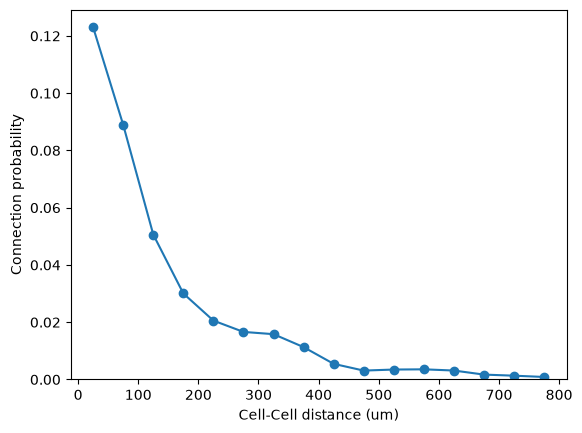

In [39]:
bin_edges = np.arange(0, 850, 50)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

n_potential = np.histogram(all_pairs_distance, bins=bin_edges)[0]
n_connected = np.histogram(connected_dist, bins=bin_edges)[0]
connection_prob = n_connected / n_potential

plt.plot(bin_centers, connection_prob, "o-")
plt.xlabel("Cell-Cell distance (um)")
plt.ylabel("Connection probability")
plt.ylim(0)
plt.show()

5. Conclusion

Neurons that are close together are much more likely to be connected. For pairs less than 50 um apart, around 12 out of 100 possible pairs are actually connected. After that it drops off quickly and once you get past 500 um there are basically no connections left. So the hypothesis is true for these 66 neurons.

### Extra

This plot shows the number of connections and the distance between them

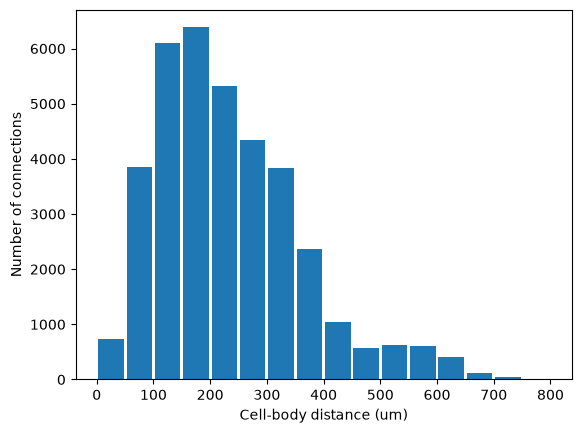

In [30]:
plt.bar(bin_centers, n_connected, width=45)
plt.xlabel("Cell-body distance (um)")
plt.ylabel("Number of connections")
plt.show()